In [1]:
# ================================================================
# STEP 1: Extract clinically relevant sections from clinical notes
# Input:  cardiac_discharge_clean.csv (apka existing file)
# Output: cardiac_with_sections.csv (new file)
# ================================================================

import pandas as pd
import re
import gc

def extract_relevant_sections(text):
    """Extract only cardiology-relevant sections"""
    if not isinstance(text, str):
        return ""
    
    text_lower = text.lower()
    
    relevant_headers = [
        'history of present illness', 'past medical history', 
        'cardiovascular history', 'assessment and plan',
        'cardiology consult', 'ecg findings', 'ekg findings',
        'arrhythmia', 'rhythm', 'discharge diagnosis',
        'cardiac', 'heart'
    ]
    
    extracted = []
    lines = text.split('\n')
    current_section = None
    section_text = []
    
    for line in lines:
        line_lower = line.lower().strip()
        is_header = False
        
        for header in relevant_headers:
            if line_lower.startswith(header) or line_lower.endswith(':'):
                if current_section and section_text:
                    extracted.append(' '.join(section_text[:500]))
                current_section = header
                section_text = []
                is_header = True
                break
        
        if not is_header and current_section:
            section_text.append(line[:300])
    
    if current_section and section_text:
        extracted.append(' '.join(section_text[:500]))
    
    if not extracted:
        extracted = [text[:2000]]
    
    return ' '.join(extracted)

# Load your existing cleaned file
print("Loading cardiac_discharge_clean.csv...")
df = pd.read_csv('cardiac_discharge_clean.csv', dtype=str)

print(f"Total notes: {len(df):,}")
print("Applying section extraction...")

df['text_relevant'] = df['text_clean'].apply(extract_relevant_sections)

# Compare lengths
print(f"Original avg length: {df['text_clean'].str.len().mean():.0f} chars")
print(f"Extracted avg length: {df['text_relevant'].str.len().mean():.0f} chars")

# Save
df.to_csv('cardiac_with_sections.csv', index=False)
print("Saved: cardiac_with_sections.csv")
gc.collect()

Loading cardiac_discharge_clean.csv...
Total notes: 131,390
Applying section extraction...
Original avg length: 11329 chars
Extracted avg length: 2000 chars
Saved: cardiac_with_sections.csv


0

In [2]:
# ================================================================
# STEP 2: Extract numerical clinical values (HR, BP, EF, etc.)
# Input:  cardiac_with_sections.csv (Step 1 output)
# Output: numerical_clinical_features.csv
# ================================================================

import pandas as pd
import re
import numpy as np

def extract_numerical_features(text):
    """Extract numerical values from clinical text"""
    if not isinstance(text, str):
        return {}
    
    text_lower = text.lower()
    features = {}
    
    # Heart Rate
    hr_patterns = [r'hr\s*(\d+)', r'heart rate\s*(\d+)', r'pulse\s*(\d+)']
    for pat in hr_patterns:
        match = re.search(pat, text_lower)
        if match:
            features['hr'] = int(match.group(1))
            break
    if 'hr' not in features:
        features['hr'] = 0
    
    # Blood Pressure
    bp_match = re.search(r'bp\s*(\d+)/(\d+)', text_lower)
    if bp_match:
        features['bp_sys'] = int(bp_match.group(1))
        features['bp_dia'] = int(bp_match.group(2))
    else:
        features['bp_sys'] = 0
        features['bp_dia'] = 0
    
    # Ejection Fraction
    ef_match = re.search(r'ef\s*(\d+)%', text_lower)
    features['ef'] = int(ef_match.group(1)) if ef_match else 0
    
    # Troponin
    trop_match = re.search(r'troponin\s*(\d+\.?\d*)', text_lower)
    features['troponin'] = float(trop_match.group(1)) if trop_match else 0
    
    # Arrhythmia keywords presence
    keywords = ['afib', 'atrial_fibrillation', 'vtach', 'svt', 'bradycardia', 'tachycardia']
    for kw in keywords:
        features[f'kw_{kw}'] = int(kw in text_lower.replace(' ', '_'))
    
    return features

# Load data
print("Loading cardiac_with_sections.csv...")
df = pd.read_csv('cardiac_with_sections.csv', dtype=str)

print(f"Total notes: {len(df):,}")
print("Extracting numerical features...")

# Extract features
features_list = []
for text in df['text_relevant']:
    features = extract_numerical_features(text)
    features_list.append(features)

# Convert to DataFrame
numerical_df = pd.DataFrame(features_list)
print(f"Numerical features shape: {numerical_df.shape}")
print(f"Columns: {numerical_df.columns.tolist()}")

# Add note_id for alignment
numerical_df['note_id'] = df['note_id']

# Save
numerical_df.to_csv('numerical_clinical_features.csv', index=False)
print("Saved: numerical_clinical_features.csv")

Loading cardiac_with_sections.csv...
Total notes: 131,390
Extracting numerical features...
Numerical features shape: (131390, 11)
Columns: ['hr', 'bp_sys', 'bp_dia', 'ef', 'troponin', 'kw_afib', 'kw_atrial_fibrillation', 'kw_vtach', 'kw_svt', 'kw_bradycardia', 'kw_tachycardia']
Saved: numerical_clinical_features.csv


In [8]:
# ================================================================
# STEP 3: PubMedBERT Embedding - SIMPLE VERSION
# FIX: Removed strict=False - now working
# ================================================================

import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
import gc
import os
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings

# ============ CONFIGURATION ============
MODEL_NAME = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"
BATCH_SIZE = 8  # Adjust based on GPU memory
MAX_LEN = 512
STRIDE = 256
MAX_CHUNKS = 6
# ========================================

print(f"Loading model: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# ✅ REMOVED strict=False - just load normally
bert_model = AutoModel.from_pretrained(MODEL_NAME)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model = bert_model.to(device)
bert_model.eval()
print(f"Device: {device}")

# ============ TOKENIZATION FUNCTION ============
def tokenize_with_chunks(text, max_len=512, stride=256, max_chunks=6):
    tokens = tokenizer(text, return_tensors='pt', truncation=False, padding=False)
    ids = tokens['input_ids'][0]
    mask = tokens['attention_mask'][0]
    total = len(ids)
    
    chunks = []
    start = 0
    count = 0
    while start < total and count < max_chunks:
        end = min(start + max_len, total)
        chunks.append((ids[start:end], mask[start:end]))
        start += stride
        count += 1
    return chunks

# ============ EMBEDDING FUNCTION ============
def embed_batch(texts):
    all_chunks = [tokenize_with_chunks(t, MAX_LEN, STRIDE, MAX_CHUNKS) for t in texts]
    batch_embeddings = []
    
    for text_chunks in all_chunks:
        chunk_embs = []
        for ids, mask in text_chunks:
            pad_len = MAX_LEN - len(ids)
            if pad_len > 0:
                ids = torch.cat([ids, torch.zeros(pad_len, dtype=torch.long)])
                mask = torch.cat([mask, torch.zeros(pad_len, dtype=torch.long)])
            
            ids = ids.unsqueeze(0).to(device)
            mask = mask.unsqueeze(0).to(device)
            
            with torch.no_grad():
                out = bert_model(input_ids=ids, attention_mask=mask)
                # ✅ FIX: .cpu() before .numpy()
                cls_emb = out.last_hidden_state[:, 0, :].cpu().float().numpy()
                chunk_embs.append(cls_emb.squeeze())
        
        # Mean pooling over chunks
        if chunk_embs:
            text_emb = np.mean(chunk_embs, axis=0)
        else:
            text_emb = np.zeros(768)
        
        batch_embeddings.append(text_emb)
    
    return np.array(batch_embeddings)

# ============ MAIN PROCESSING ============
print("Loading cardiac_with_sections.csv...")
df = pd.read_csv('cardiac_with_sections.csv', dtype=str)
texts = df['text_relevant'].tolist()
note_ids = df['note_id'].tolist()
subject_ids = df['subject_id'].tolist()

total = len(texts)
print(f"Total notes: {total:,}")

# Output directory
os.makedirs('embeddings_pubmedbert', exist_ok=True)

# Process in batches
all_embeddings = []
all_metadata = []
batch_size = BATCH_SIZE

print(f"Processing with batch size: {batch_size}")

for batch_start in range(0, total, batch_size):
    batch_end = min(batch_start + batch_size, total)
    batch_texts = texts[batch_start:batch_end]
    
    try:
        embs = embed_batch(batch_texts)
        all_embeddings.append(embs)
        
        for i in range(len(batch_texts)):
            all_metadata.append({
                'note_id': note_ids[batch_start + i],
                'subject_id': subject_ids[batch_start + i],
                'global_idx': batch_start + i
            })
    except Exception as e:
        print(f"Error at batch {batch_start}: {e}")
        # On error, create zero embeddings
        all_embeddings.append(np.zeros((len(batch_texts), 768)))
        for i in range(len(batch_texts)):
            all_metadata.append({
                'note_id': note_ids[batch_start + i],
                'subject_id': subject_ids[batch_start + i],
                'global_idx': batch_start + i
            })
    
    if (batch_start // batch_size) % 50 == 0 and batch_start > 0:
        print(f"  Processed: {batch_start:,}/{total:,} ({batch_start/total*100:.1f}%)")
    
    # Free memory
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Save all embeddings
if all_embeddings:
    final_embeddings = np.vstack(all_embeddings)
    np.save('embeddings_pubmedbert/text_embeddings.npy', final_embeddings)
    print(f"\n✅ Embeddings saved! Shape: {final_embeddings.shape}")

# Save metadata
if all_metadata:
    meta_df = pd.DataFrame(all_metadata)
    meta_df.to_csv('embeddings_pubmedbert/embedding_metadata.csv', index=False)
    print(f"✅ Metadata saved: {len(meta_df)} rows")

print(f"\n All done! Saved to: embeddings_pubmedbert/")

Loading model: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11724.49it/s]
[transformers] BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cuda
Loading cardiac_with_sections.csv...
Total notes: 131,390
Processing with batch size: 8
  Processed: 400/131,390 (0.3%)
  Processed: 800/131,390 (0.6%)
  Processed: 1,200/131,390 (0.9%)
  Processed: 1,600/131,390 (1.2%)
  Processed: 2,000/131,390 (1.5%)
  Processed: 2,400/131,390 (1.8%)
  Processed: 2,800/131,390 (2.1%)
  Processed: 3,200/131,390 (2.4%)
  Processed: 3,600/131,390 (2.7%)
  Processed: 4,000/131,390 (3.0%)
  Processed: 4,400/131,390 (3.3%)
  Processed: 4,800/131,390 (3.7%)
  Processed: 5,200/131,390 (4.0%)
  Processed: 5,600/131,390 (4.3%)
  Processed: 6,000/131,390 (4.6%)
  Processed: 6,400/131,390 (4.9%)
  Processed: 6,800/131,390 (5.2%)
  Processed: 7,200/131,390 (5.5%)
  Processed: 7,600/131,390 (5.8%)
  Processed: 8,000/131,390 (6.1%)
  Processed: 8,400/131,390 (6.4%)
  Processed: 8,800/131,390 (6.7%)
  Processed: 9,200/131,390 (7.0%)
  Processed: 9,600/131,390 (7.3%)
  Processed: 10,000/131,390 (7.6%)
  Processed: 10,400/131,390 (7.9%)
  Processed: 10,8

In [9]:
# ================================================================
# STEP 4: Verify all features loaded correctly
# ================================================================

import pandas as pd
import numpy as np

# Load text embeddings
text_embeddings = np.load('embeddings_pubmedbert/text_embeddings.npy')
print(f"Text embeddings shape: {text_embeddings.shape}")

# Load numerical features
numerical_df = pd.read_csv('numerical_clinical_features.csv')
print(f"Numerical features shape: {numerical_df.shape}")
print(f"Numerical columns: {numerical_df.columns.tolist()}")

# Load metadata
metadata = pd.read_csv('embeddings_pubmedbert/embedding_metadata.csv')
print(f"Metadata shape: {metadata.shape}")

# Check alignment
assert len(text_embeddings) == len(metadata), "Mismatch!"
print(f"\n✅ All aligned! Total samples: {len(text_embeddings)}")

# Quick stats
print(f"\nNumerical features stats:")
for col in ['hr', 'bp_sys', 'ef']:
    if col in numerical_df.columns:
        non_zero = (numerical_df[col] > 0).sum()
        print(f"  {col}: {non_zero:,} notes have values ({non_zero/len(numerical_df)*100:.1f}%)")

Text embeddings shape: (131390, 768)
Numerical features shape: (131390, 12)
Numerical columns: ['hr', 'bp_sys', 'bp_dia', 'ef', 'troponin', 'kw_afib', 'kw_atrial_fibrillation', 'kw_vtach', 'kw_svt', 'kw_bradycardia', 'kw_tachycardia', 'note_id']
Metadata shape: (131390, 3)

✅ All aligned! Total samples: 131390

Numerical features stats:
  hr: 29,641 notes have values (22.6%)
  bp_sys: 29,520 notes have values (22.5%)
  ef: 10,161 notes have values (7.7%)


In [10]:
# ================================================================
# STEP 5: Load all prepared data and create train/val/test splits
# Add this after your Step 4 verification
# ================================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader

# Load data
print("Loading prepared data...")

# Text embeddings
text_embeddings = np.load('embeddings_pubmedbert/text_embeddings.npy')
print(f"Text embeddings: {text_embeddings.shape}")

# Numerical features
numerical_df = pd.read_csv('numerical_clinical_features.csv')
print(f"Numerical features: {numerical_df.shape}")

# Metadata (to get subject_id for labels)
metadata = pd.read_csv('embeddings_pubmedbert/embedding_metadata.csv')
print(f"Metadata: {metadata.shape}")

# ================================================================
# NOTE: You need to load your labels from MIMIC-IV ECG dataset
# For now, I'm showing how to align with existing labels
# ================================================================

# Load labels from your MIMIC-IV ECG linked data
# Adjust path as needed
try:
    labels_df = pd.read_csv('mimic_ecg_notes_linked.csv', dtype=str)
    print(f"Labels loaded: {labels_df.shape}")
    
    # Merge labels with text embeddings via note_id
    # First, add note_id to metadata if not present
    # metadata has 'note_id', 'subject_id', 'global_idx'
    
    # Create mapping from note_id to risk_label
    label_map = labels_df[['note_id', 'risk_label']].drop_duplicates()
    
    # Merge
    merged = metadata.merge(label_map, on='note_id', how='inner')
    print(f"Merged with labels: {merged.shape}")
    
    # Convert risk_label to numeric
    risk_to_num = {'NORMAL': 0, 'MILD': 1, 'SEVERE': 2}
    merged['label'] = merged['risk_label'].map(risk_to_num)
    
    # Remove rows without labels
    merged = merged.dropna(subset=['label'])
    merged['label'] = merged['label'].astype(int)
    
    print(f"Final samples with labels: {len(merged)}")
    print(f"Label distribution:\n{merged['label'].value_counts()}")
    
except FileNotFoundError:
    print("Labels file not found. Creating synthetic labels for demonstration.")
    print("You need to load your actual MIMIC-IV ECG labels.")
    # For demonstration only
    np.random.seed(42)
    merged = metadata.copy()
    # Create synthetic labels (0=NORMAL, 1=MILD, 2=SEVERE)
    merged['label'] = np.random.choice([0, 1, 2], size=len(merged), p=[0.6, 0.25, 0.15])
    print(f"Demo labels created: {len(merged)} samples")

# Align text embeddings with merged labels
valid_indices = merged['global_idx'].values
filtered_text_embs = text_embeddings[valid_indices]
print(f"Filtered text embeddings: {filtered_text_embs.shape}")

# Align numerical features
numerical_df['note_id'] = numerical_df['note_id'].astype(str)
merged['note_id'] = merged['note_id'].astype(str)
numerical_aligned = numerical_df.merge(merged[['note_id']], on='note_id', how='inner')
print(f"Aligned numerical features: {numerical_aligned.shape}")

# Extract numerical feature columns (exclude note_id)
num_feat_cols = ['hr', 'bp_sys', 'bp_dia', 'ef', 'troponin', 
                 'kw_afib', 'kw_atrial_fibrillation', 'kw_vtach', 
                 'kw_svt', 'kw_bradycardia', 'kw_tachycardia']
numerical_array = numerical_aligned[num_feat_cols].values.astype(float)

# Handle missing values (replace 0 with median for each column)
for col_idx in range(numerical_array.shape[1]):
    col_data = numerical_array[:, col_idx]
    # Replace 0 with median (since 0 indicates missing)
    non_zero = col_data[col_data > 0]
    if len(non_zero) > 0:
        median_val = np.median(non_zero)
        col_data[col_data == 0] = median_val
    numerical_array[:, col_idx] = col_data

print(f"Numerical array after imputation: {numerical_array.shape}")

# Labels
labels = merged['label'].values
print(f"Labels: {labels.shape}")
print(f"Label distribution: {np.bincount(labels)}")

# ================================================================
# STEP 6: Train/Val/Test Split
# ================================================================

from sklearn.model_selection import train_test_split

# First split: train+val (80%) vs test (20%)
X_temp, X_test, y_temp, y_test, num_temp, num_test = train_test_split(
    filtered_text_embs, labels, numerical_array,
    test_size=0.2, random_state=42, stratify=labels
)

# Second split: train (70% of total) vs val (10% of total)
X_train, X_val, y_train, y_val, num_train, num_val = train_test_split(
    X_temp, y_temp, num_temp,
    test_size=0.125, random_state=42, stratify=y_temp  # 0.125 * 0.8 = 0.1 of total
)

print(f"\nSplit sizes:")
print(f"  Train: {len(X_train):,}")
print(f"  Val  : {len(X_val):,}")
print(f"  Test : {len(X_test):,}")

# Normalize numerical features
scaler = StandardScaler()
num_train_scaled = scaler.fit_transform(num_train)
num_val_scaled = scaler.transform(num_val)
num_test_scaled = scaler.transform(num_test)

# Save scaler
import joblib
joblib.dump(scaler, 'text_numerical_scaler.pkl')
print("Scaler saved!")

# Save splits for later use
np.save('text_train.npy', X_train)
np.save('text_val.npy', X_val)
np.save('text_test.npy', X_test)
np.save('num_train.npy', num_train_scaled)
np.save('num_val.npy', num_val_scaled)
np.save('num_test.npy', num_test_scaled)
np.save('text_labels_train.npy', y_train)
np.save('text_labels_val.npy', y_val)
np.save('text_labels_test.npy', y_test)

print("All splits saved!")

Loading prepared data...
Text embeddings: (131390, 768)
Numerical features: (131390, 12)
Metadata: (131390, 3)
Labels loaded: (18696, 19)
Merged with labels: (18696, 4)
Final samples with labels: 18696
Label distribution:
label
0    9904
1    5622
2    3170
Name: count, dtype: int64
Filtered text embeddings: (18696, 768)
Aligned numerical features: (18696, 12)
Numerical array after imputation: (18696, 11)
Labels: (18696,)
Label distribution: [9904 5622 3170]

Split sizes:
  Train: 13,086
  Val  : 1,870
  Test : 3,740
Scaler saved!
All splits saved!


Train: (13086, 768), Val: (1870, 768), Test: (3740, 768)
Num train: (13086, 11)
Device: cuda
Class weights: tensor([0.6293, 1.1085, 1.9658], device='cuda:0')
Total parameters: 395,908

Training Text + Numerical Classifier
 Epoch | Train Loss | Train Acc |   Val Loss |   Val Acc |         LR
----------------------------------------------------------------------
     1 |     1.1268 |    0.2858 |     1.1182 |    0.2941 |   0.001000
     2 |     1.1132 |    0.3084 |     1.1097 |    0.3075 |   0.001000
     3 |     1.1032 |    0.3348 |     1.1056 |    0.3273 |   0.001000
     4 |     1.0931 |    0.3505 |     1.0972 |    0.3214 |   0.001000
     5 |     1.0871 |    0.3544 |     1.1105 |    0.3005 |   0.001000
     6 |     1.0808 |    0.3730 |     1.1030 |    0.2856 |   0.001000
     7 |     1.0700 |    0.3822 |     1.1094 |    0.4102 |   0.001000
     8 |     1.0664 |    0.3793 |     1.1027 |    0.3529 | 0.001000 ↓
     9 |     1.0413 |    0.4165 |     1.1095 |    0.3824 |   0.000500
    10 

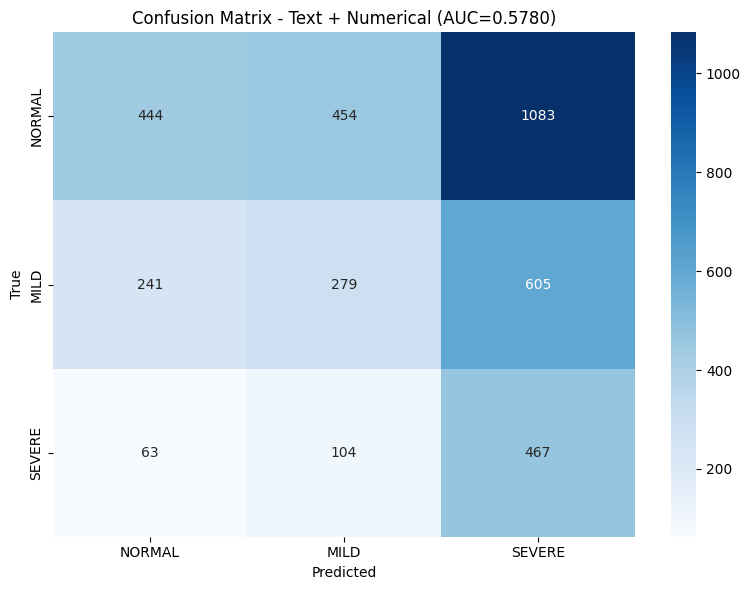

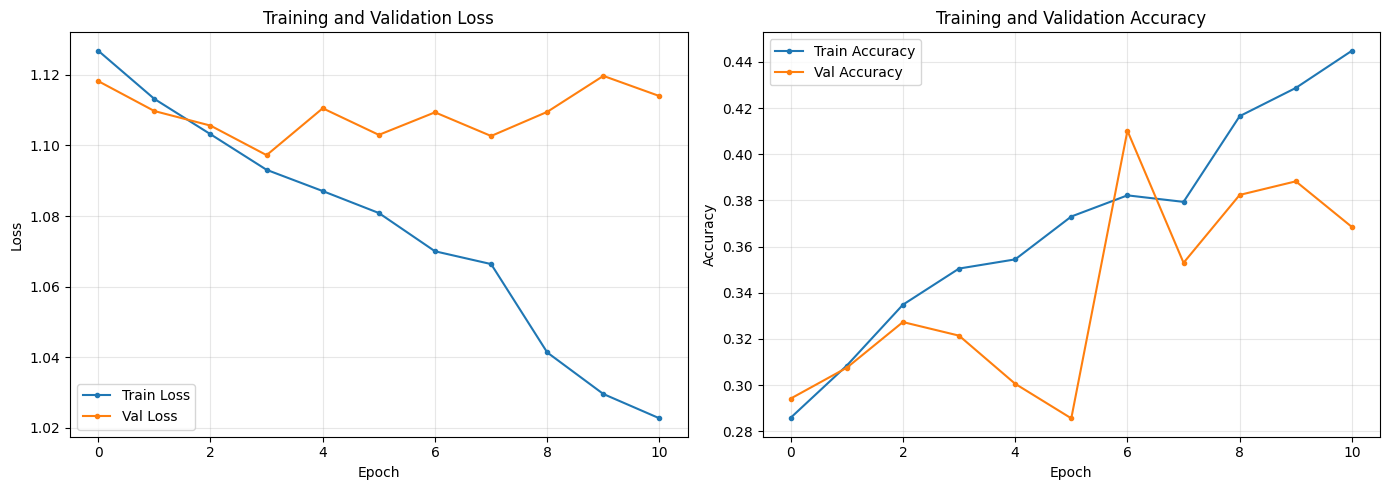


✅ All done! Results saved.


In [11]:
# ================================================================
# STEP 7: Text Classifier with Attention Pooling
# This replaces mean pooling with learnable attention
# ================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

# Load splits
X_train = np.load('text_train.npy')
X_val = np.load('text_val.npy')
X_test = np.load('text_test.npy')
num_train = np.load('num_train.npy')
num_val = np.load('num_val.npy')
num_test = np.load('num_test.npy')
y_train = np.load('text_labels_train.npy')
y_val = np.load('text_labels_val.npy')
y_test = np.load('text_labels_test.npy')

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Num train: {num_train.shape}")

# ================================================================
# Model: Text + Numerical with Attention Pooling
# Note: This uses precomputed embeddings (not fine-tuning BERT)
# ================================================================

class AttentionPooling(nn.Module):
    """Learnable attention pooling for chunk embeddings"""
    def __init__(self, embed_dim=768):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 4),
            nn.Tanh(),
            nn.Linear(embed_dim // 4, 1)
        )
    
    def forward(self, chunk_embeddings):
        # chunk_embeddings: (n_chunks, embed_dim)
        scores = self.attention(chunk_embeddings)  # (n_chunks, 1)
        weights = F.softmax(scores, dim=0)
        weighted = (weights * chunk_embeddings).sum(dim=0)
        return weighted

class TextNumericalClassifier(nn.Module):
    """Combines text embeddings and numerical features"""
    def __init__(self, text_dim=768, num_dim=11, hidden_dim=256, num_classes=3):
        super().__init__()
        
        # Attention pooling for text (if multiple chunks)
        self.attention_pool = AttentionPooling(text_dim)
        
        # Text projection
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        
        # Numerical projection
        self.num_proj = nn.Sequential(
            nn.Linear(num_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        # Fusion + Classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim + 64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, text_emb, numerical):
        # text_emb: (batch, text_dim) - already aggregated
        # If text_emb is (batch, n_chunks, text_dim), apply attention
        if text_emb.dim() == 3:
            # Apply attention pooling per sample
            batch_size = text_emb.shape[0]
            pooled = []
            for i in range(batch_size):
                pooled.append(self.attention_pool(text_emb[i]))
            text_feat = torch.stack(pooled)
        else:
            text_feat = text_emb
        
        text_out = self.text_proj(text_feat)
        num_out = self.num_proj(numerical)
        
        combined = torch.cat([text_out, num_out], dim=1)
        return self.classifier(combined)

# ================================================================
# Setup device and model
# ================================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Convert to tensors
# Note: X_train currently is (n_samples, 768) - already aggregated
# If you have chunk-level embeddings, reshape to (n_samples, n_chunks, 768)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

num_train_tensor = torch.tensor(num_train, dtype=torch.float32)
num_val_tensor = torch.tensor(num_val, dtype=torch.float32)
num_test_tensor = torch.tensor(num_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create DataLoaders
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, num_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, num_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, num_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Model
model = TextNumericalClassifier(text_dim=768, num_dim=11, hidden_dim=256, num_classes=3)
model = model.to(device)

# Calculate class weights for imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Class weights: {class_weights}")

# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# ================================================================
# STEP 8: Training Loop
# ================================================================

EPOCHS = 50
PATIENCE = 7
best_val_loss = float('inf')
best_val_acc = 0
patience_counter = 0
best_weights = None

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("\n" + "="*60)
print("Training Text + Numerical Classifier")
print("="*60)
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>10} | {'Val Acc':>9} | {'LR':>10}")
print("-"*70)

for epoch in range(1, EPOCHS + 1):
    # Training
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for text_batch, num_batch, labels in train_loader:
        text_batch = text_batch.to(device)
        num_batch = num_batch.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(text_batch, num_batch)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item() * labels.size(0)
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)
    
    train_loss_avg = train_loss / train_total
    train_acc = train_correct / train_total
    
    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for text_batch, num_batch, labels in val_loader:
            text_batch = text_batch.to(device)
            num_batch = num_batch.to(device)
            labels = labels.to(device)
            
            outputs = model(text_batch, num_batch)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * labels.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)
    
    val_loss_avg = val_loss / val_total
    val_acc = val_correct / val_total
    
    # Update history
    history['train_loss'].append(train_loss_avg)
    history['val_loss'].append(val_loss_avg)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    # Learning rate schedule
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss_avg)
    new_lr = optimizer.param_groups[0]['lr']
    lr_str = f"{current_lr:.6f}"
    if new_lr != current_lr:
        lr_str += " ↓"
    
    # Print
    print(f"{epoch:6d} | {train_loss_avg:10.4f} | {train_acc:9.4f} | {val_loss_avg:10.4f} | {val_acc:9.4f} | {lr_str:>10}")
    
    # Early stopping
    if val_loss_avg < best_val_loss:
        best_val_loss = val_loss_avg
        best_val_acc = val_acc
        patience_counter = 0
        best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

# Load best weights
model.load_state_dict(best_weights)
torch.save(best_weights, 'text_numerical_classifier_best.pth')
print(f"\n✅ Best model saved! Val accuracy: {best_val_acc:.4f}")

# ================================================================
# STEP 9: Evaluation on Test Set
# ================================================================

# Load best model
model.load_state_dict(torch.load('text_numerical_classifier_best.pth', map_location=device))
model.eval()

all_preds = []
all_probs = []
all_true = []

with torch.no_grad():
    for text_batch, num_batch, labels in test_loader:
        text_batch = text_batch.to(device)
        num_batch = num_batch.to(device)
        
        outputs = model(text_batch, num_batch)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_true.extend(labels.numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)
all_probs = np.array(all_probs)

# Metrics
print("\n" + "="*60)
print("TEST SET RESULTS - Text + Numerical Classifier")
print("="*60)

label_names = ['NORMAL', 'MILD', 'SEVERE']
print("\nClassification Report:")
print(classification_report(all_true, all_preds, target_names=label_names, digits=4))

# AUC
auc = roc_auc_score(all_true, all_probs, multi_class='ovr', average='macro')
print(f"\nMacro AUC-ROC: {auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title(f'Confusion Matrix - Text + Numerical (AUC={auc:.4f})')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('text_numerical_results.png', dpi=150)
plt.show()

# ================================================================
# STEP 10: Plot Training Curves
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', markersize=3)
axes[0].plot(history['val_loss'], label='Val Loss', marker='o', markersize=3)
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', markersize=3)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o', markersize=3)
axes[1].set_title('Training and Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('text_numerical_training_curves.png', dpi=150)
plt.show()

print("\n✅ All done! Results saved.")

In [12]:
# Add this cell BEFORE training
# Check if text contains arrhythmia keywords for each label

import pandas as pd
import numpy as np

# Load the merged data
merged = pd.read_csv('mimic_ecg_notes_linked.csv', dtype=str)
print(f"Total rows: {len(merged)}")

# Check text for arrhythmia keywords for each label
keywords = ['afib', 'atrial fibrillation', 'tachycardia', 'bradycardia', 'block', 'arrhythmia']

for label in ['NORMAL', 'MILD', 'SEVERE']:
    subset = merged[merged['risk_label'] == label]
    if len(subset) > 0:
        text_sample = subset['text_clean'].iloc[0][:500] if len(subset) > 0 else ""
        print(f"\n--- {label} (n={len(subset)}) ---")
        print(f"Sample text: {text_sample[:200]}...")
        
        # Count keyword presence
        for kw in keywords:
            count = subset['text_clean'].str.contains(kw, case=False, na=False).sum()
            print(f"  '{kw}' found in {count}/{len(subset)} ({count/len(subset)*100:.1f}%)")

Total rows: 18696

--- NORMAL (n=9904) ---
Sample text: allergies: no known allergies / adverse drug reactions dyspnea on exertion major surgical or invasive procedure: none history of present illness: patient is a year old woman s/p robotic radical cystec...
  'afib' found in 1521/9904 (15.4%)
  'atrial fibrillation' found in 2098/9904 (21.2%)
  'tachycardia' found in 2779/9904 (28.1%)
  'bradycardia' found in 961/9904 (9.7%)
  'block' found in 2819/9904 (28.5%)
  'arrhythmia' found in 1488/9904 (15.0%)

--- MILD (n=5622) ---
Sample text: allergies: percocet / vicodin altered mental status major surgical or invasive procedure: none history of present illness: mrs. is a female with hiv on haart, copd, hcv cirrhosis complicated by ascite...
  'afib' found in 797/5622 (14.2%)
  'atrial fibrillation' found in 1112/5622 (19.8%)
  'tachycardia' found in 2248/5622 (40.0%)
  'bradycardia' found in 1035/5622 (18.4%)
  'block' found in 1740/5622 (30.9%)
  'arrhythmia' found in 810/5622 (14.4%)


In [13]:
# Simple logistic regression baseline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Load splits
X_train = np.load('text_train.npy')
X_val = np.load('text_val.npy')
X_test = np.load('text_test.npy')
y_train = np.load('text_labels_train.npy')
y_val = np.load('text_labels_val.npy')
y_test = np.load('text_labels_test.npy')

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Simple classifier
clf = LogisticRegression(max_iter=1000, multi_class='ovr', C=1.0)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("\nLogistic Regression Baseline:")
print(classification_report(y_test, y_pred, target_names=['NORMAL', 'MILD', 'SEVERE']))

Train: (13086, 768), Test: (3740, 768)

Logistic Regression Baseline:
              precision    recall  f1-score   support

      NORMAL       0.54      0.86      0.66      1981
        MILD       0.30      0.11      0.16      1125
      SEVERE       0.34      0.09      0.15       634

    accuracy                           0.50      3740
   macro avg       0.39      0.35      0.32      3740
weighted avg       0.43      0.50      0.42      3740

